In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q pyspark delta-spark pyarrow pandas

In [ ]:
from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip

builder = SparkSession.builder \
    .appName("TLC_Delta_Pipeline") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")

spark = configure_spark_with_delta_pip(builder).getOrCreate()
print("Spark + Delta ready:", spark.version)

Spark + Delta ready: 4.0.2


# Path Definitions

In [ ]:
# Define paths for each medallion layer
BRONZE_PATH = "/content/drive/MyDrive/tlc_data/bronze/"
SILVER_PATH = "/content/drive/MyDrive/tlc_data/silver/"
GOLD_PATH   = "/content/drive/MyDrive/tlc_data/gold/"

print("Paths defined:")
print(f"  Bronze: {BRONZE_PATH}")
print(f"  Silver: {SILVER_PATH}")
print(f"  Gold:   {GOLD_PATH}")

Paths defined:
  Bronze: /content/drive/MyDrive/tlc_data/bronze/
  Silver: /content/drive/MyDrive/tlc_data/silver/
  Gold:   /content/drive/MyDrive/tlc_data/gold/


# Bronze Layer Ingestion

In [ ]:
RAW_PARQUET_DATA = "/content/drive/MyDrive/tlc_data/raw/"

bronze_df = spark.read.parquet(RAW_PARQUET_DATA)
print(f"Records loaded: {bronze_df.count():,}")
print(f"Columns: {len(bronze_df.columns)}")
bronze_df.printSchema()

Records loaded: 16,792,900
Columns: 19
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



In [ ]:
bronze_df.write.format("delta").mode("overwrite").save(BRONZE_PATH)

print("Bronze layer written!")

Bronze layer written!


In [ ]:
import pandas as pd

# Fetch zone lookup directly from TLC
zone_pd = pd.read_csv("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
print(zone_pd.head())
print(f"Zone records: {len(zone_pd)}")

# Convert to Spark and write to Bronze
zone_spark = spark.createDataFrame(zone_pd)
zone_spark.write.format("delta").mode("overwrite").save(BRONZE_PATH + "zone_lookup/")
print("Zone lookup Bronze written!")

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone
Zone records: 265
Zone lookup Bronze written!


In [ ]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 40.71,
    "longitude": -74.01,
    "start_date": "2024-01-01",
    "end_date": "2024-05-31",
    "hourly": "temperature_2m,precipitation,windspeed_10m",
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
data = response.json()

# Flatten the JSON — each key in "hourly" is a parallel array
weather_pd = pd.DataFrame({
    "datetime": data["hourly"]["time"],
    "temperature_c": data["hourly"]["temperature_2m"],
    "precipitation_mm": data["hourly"]["precipitation"],
    "windspeed_kmh": data["hourly"]["windspeed_10m"]
})

# Parse datetime and extract join keys
weather_pd["datetime"] = pd.to_datetime(weather_pd["datetime"])
weather_pd["pickup_date"] = weather_pd["datetime"].dt.date.astype(str)
weather_pd["pickup_hour"] = weather_pd["datetime"].dt.hour

print(weather_pd.head())
print(f"Weather records: {len(weather_pd)}")

# Write to Bronze
weather_spark = spark.createDataFrame(weather_pd)
weather_spark.write.format("delta").mode("overwrite").save(BRONZE_PATH + "weather/")
print("Weather Bronze written!")

             datetime  temperature_c  precipitation_mm  windspeed_kmh  \
0 2024-01-01 00:00:00            1.9               0.0            6.3   
1 2024-01-01 01:00:00            1.8               0.0            8.9   
2 2024-01-01 02:00:00            2.8               0.0           11.4   
3 2024-01-01 03:00:00            2.9               0.0            9.7   
4 2024-01-01 04:00:00            2.8               0.0            8.1   

  pickup_date  pickup_hour  
0  2024-01-01            0  
1  2024-01-01            1  
2  2024-01-01            2  
3  2024-01-01            3  
4  2024-01-01            4  
Weather records: 3648
Weather Bronze written!


# Silver Layer Cleaning & Feature Engineering

In [ ]:
from pyspark.sql.functions import col, hour, dayofweek, month, when, round, unix_timestamp

silver_df = bronze_df \
    .dropDuplicates() \
    .dropna(subset=["tpep_pickup_datetime", "tpep_dropoff_datetime", "fare_amount"]) \
    .filter(
        (col("fare_amount") > 0) &
        (col("trip_distance") > 0) &
        (col("passenger_count") > 0) &
        (col("passenger_count") <= 6)
    ) \
    .withColumn("pickup_hour", hour("tpep_pickup_datetime")) \
    .withColumn("pickup_day", dayofweek("tpep_pickup_datetime")) \
    .withColumn("pickup_month", month("tpep_pickup_datetime")) \
    .withColumn("trip_duration_min",
        round((unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60, 2)) \
    .withColumn("payment_label", when(col("payment_type") == 1, "Credit Card")
                                 .when(col("payment_type") == 2, "Cash")
                                 .otherwise("Other"))

    # Read Bronze sources
zone_bronze = spark.read.format("delta").load(BRONZE_PATH + "zone_lookup/")
weather_bronze = spark.read.format("delta").load(BRONZE_PATH + "weather/")

# --- Join Zone Lookup (pickup location) ---
pickup_zone = zone_bronze \
    .withColumnRenamed("LocationID", "PULocationID") \
    .withColumnRenamed("Borough", "pickup_borough") \
    .withColumnRenamed("Zone", "pickup_zone") \
    .withColumnRenamed("service_zone", "pickup_service_zone")

dropoff_zone = zone_bronze \
    .withColumnRenamed("LocationID", "DOLocationID") \
    .withColumnRenamed("Borough", "dropoff_borough") \
    .withColumnRenamed("Zone", "dropoff_zone") \
    .withColumnRenamed("service_zone", "dropoff_service_zone")

silver_df = silver_df \
    .join(pickup_zone, on="PULocationID", how="left") \
    .join(dropoff_zone, on="DOLocationID", how="left")

# --- Join Weather (on date + hour) ---
from pyspark.sql.functions import to_date, col

silver_df = silver_df.withColumn(
    "pickup_date", to_date("tpep_pickup_datetime")
)

weather_bronze = weather_bronze \
    .withColumn("pickup_date", col("pickup_date").cast("date"))

silver_df = silver_df.join(
    weather_bronze.select("pickup_date", "pickup_hour",
                          "temperature_c", "precipitation_mm", "windspeed_kmh"),
    on=["pickup_date", "pickup_hour"],
    how="left"
)

# Now write enriched Silver
silver_df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(SILVER_PATH)
print("Enriched Silver written!")

Enriched Silver written!


# Silver to Gold

In [ ]:
from pyspark.sql.functions import avg, count, sum as _sum, round

gold_df = silver_df \
    .groupBy("pickup_hour", "pickup_day", "payment_label") \
    .agg(
        count("*").alias("total_trips"),
        round(avg("fare_amount"), 2).alias("avg_fare"),
        round(avg("trip_distance"), 2).alias("avg_distance"),
        round(avg("trip_duration_min"), 2).alias("avg_duration_min"),
        round(_sum("fare_amount"), 2).alias("total_revenue")
    )

# Write to Gold Delta
gold_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save(GOLD_PATH)

print("Gold layer written!")

Gold layer written!


In [ ]:
from sklearn.ensemble import IsolationForest
from pyspark.sql.functions import pandas_udf, col
from pyspark.sql.types import IntegerType
import pandas as pd

# Recreate Spark session if lost
from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip

builder = SparkSession.builder \
    .appName("TLC_Delta_Pipeline") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")

spark = configure_spark_with_delta_pip(builder).getOrCreate()
# Read Silver from Delta
silver_delta = spark.read.format("delta").load(SILVER_PATH)

features = [
    "fare_amount",
    "trip_distance",
    "trip_duration_min",
    "passenger_count",
    "temperature_c",
    "precipitation_mm"
    ]

# Step 1 — Train on 10% sample
sample_pd = silver_delta.select(features).dropna() \
    .sample(fraction=0.1, seed=42) \
    .toPandas()

iso = IsolationForest(contamination=0.02, random_state=42)
iso.fit(sample_pd)
print(f"Model trained on {len(sample_pd):,} samples")

# Step 2 — Apply to full dataset via Pandas UDF
@pandas_udf(IntegerType())
def predict_anomaly(*cols):
    X = pd.concat(cols, axis=1)
    X.columns = features
    return pd.Series(iso.predict(X))

# Step 3 — Flag anomalies across full Silver layer
silver_with_flags = silver_delta.dropna(subset=features) \
    .withColumn("anomaly_flag", predict_anomaly(*[col(f) for f in features]))

# Step 4 — Split clean vs anomalous
SILVER_VALIDATED_PATH = "/content/drive/MyDrive/tlc_data/silver_validated/"
SILVER_ANOMALIES_PATH = "/content/drive/MyDrive/tlc_data/silver_anomalies/"

silver_validated = silver_with_flags.filter(col("anomaly_flag") == 1)
silver_anomalies = silver_with_flags.filter(col("anomaly_flag") == -1)

silver_validated.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(SILVER_VALIDATED_PATH)
silver_anomalies.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(SILVER_ANOMALIES_PATH)

print(f"Clean rows: {silver_validated.count():,}")
print(f"Anomalies: {silver_anomalies.count():,}")

Model trained on 1,466,766 samples
Clean rows: 14,368,052
Anomalies: 292,008


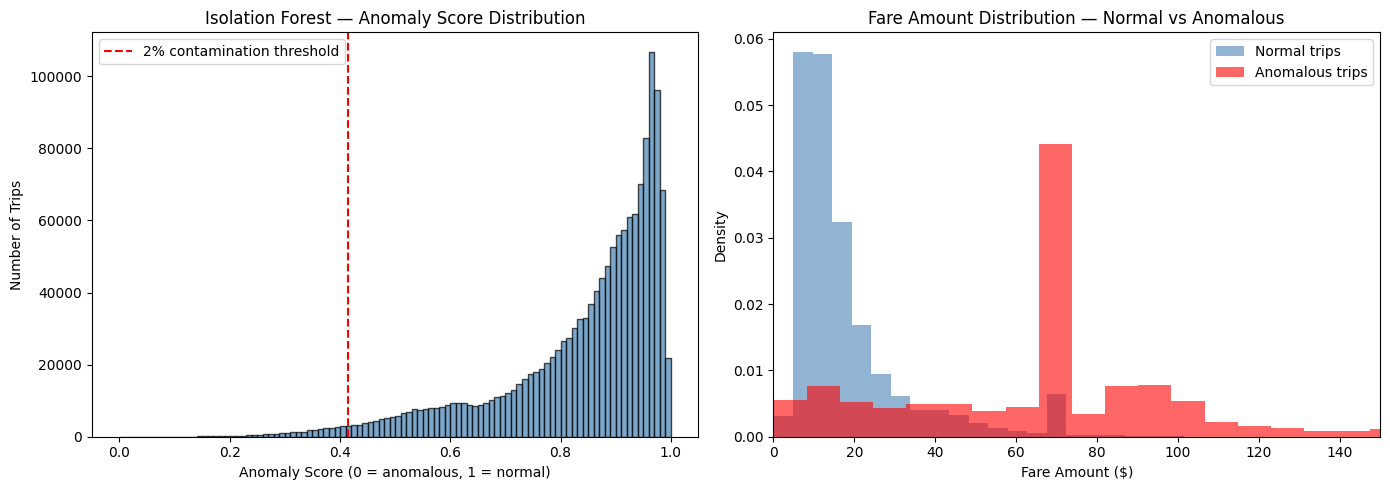

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Re-read Silver if spark session was lost
silver_delta = spark.read.format("delta").load(SILVER_PATH)

# Get anomaly scores from the model (not just -1/1 labels)
silver_pd_full = silver_delta.select(features).dropna() \
    .sample(fraction=0.1, seed=42) \
    .toPandas()
anomaly_scores = iso.decision_function(silver_pd_full)

# decision_function returns negative scores — lower = more anomalous
# Convert to positive scale for easier reading
anomaly_scores_normalized = (anomaly_scores - anomaly_scores.min()) / \
                            (anomaly_scores.max() - anomaly_scores.min())

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left — Anomaly score distribution
ax1.hist(anomaly_scores_normalized, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=np.percentile(anomaly_scores_normalized, 2),
            color='red', linestyle='--', label='2% contamination threshold')
ax1.set_title('Isolation Forest — Anomaly Score Distribution')
ax1.set_xlabel('Anomaly Score (0 = anomalous, 1 = normal)')
ax1.set_ylabel('Number of Trips')
ax1.legend()

# Right — Fare amount distribution: normal vs anomalous
silver_pd_full['anomaly_flag'] = iso.predict(silver_pd_full[features])
silver_pd_full['fare_amount_raw'] = silver_pd_full['fare_amount']

normal = silver_pd_full[silver_pd_full['anomaly_flag'] == 1]['fare_amount_raw']
anomalous = silver_pd_full[silver_pd_full['anomaly_flag'] == -1]['fare_amount_raw']

ax2.hist(normal, bins=100, color='steelblue', alpha=0.6, label='Normal trips', density=True)
ax2.hist(anomalous, bins=100, color='red', alpha=0.6, label='Anomalous trips', density=True)
ax2.set_xlim(0, 150)  # cap at $150 for readability
ax2.set_title('Fare Amount Distribution — Normal vs Anomalous')
ax2.set_xlabel('Fare Amount ($)')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql.functions import monotonically_increasing_id

# Read from silver validated
silver_validated = spark.read.format("delta").load(SILVER_VALIDATED_PATH)

# DIM_TIME
dim_time = silver_validated \
    .select("pickup_hour", "pickup_day", "pickup_month") \
    .distinct() \
    .withColumn("time_id", monotonically_increasing_id())       # surrogate key

# DIM_PAYMENT
dim_payment = silver_validated \
    .select("payment_type", "payment_label") \
    .distinct() \
    .withColumn("payment_id", monotonically_increasing_id())    # surrogate key

# DIM_LOCATION
dim_location = silver_validated \
    .select("PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone") \
    .distinct() \
    .withColumn("location_id", monotonically_increasing_id())

dim_location.write.format("delta").mode("overwrite").save(GOLD_PATH + "dim_location/")
print("dim_location written!")

# Write dimension tables to Delta
dim_time.write.format("delta").mode("overwrite").save(GOLD_PATH + "dim_time/")
dim_payment.write.format("delta").mode("overwrite").save(GOLD_PATH + "dim_payment/")

print("Dimension tables written!")

dim_location written!
Dimension tables written!


In [ ]:
from pyspark.sql.functions import avg, count, sum as _sum, round

# FACT_TRIPS — aggregated metrics
fact_trips = silver_validated \
    .groupBy("pickup_hour", "pickup_day", "pickup_month", "payment_label", "PULocationID") \
    .agg(
        count("*").alias("total_trips"),
        round(avg("fare_amount"), 2).alias("avg_fare"),
        round(avg("trip_distance"), 2).alias("avg_distance"),
        round(avg("trip_duration_min"), 2).alias("avg_duration_min"),
        round(_sum("fare_amount"), 2).alias("total_revenue")
    )

# Join with dimension keys
fact_trips = fact_trips \
    .join(dim_time, ["pickup_hour", "pickup_day", "pickup_month"]) \
    .join(dim_payment, ["payment_label"]) \
    .join(dim_location, ["PULocationID"]) \
    .select("time_id", "payment_id", "location_id", "total_trips",
            "avg_fare", "avg_distance", "avg_duration_min", "total_revenue")

# Write fact table to Delta
fact_trips.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(GOLD_PATH + "fact_trips/")

print("Fact table written!")
print(f"Gold layer complete — {fact_trips.count():,} rows")

Fact table written!
Gold layer complete — 265,712 rows


In [ ]:
# In Colab — export Gold tables as clean Parquet for Power BI
fact_trips.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/tlc_data/powerbi/fact_trips/"
)
dim_time.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/tlc_data/powerbi/dim_time/"
)
dim_payment.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/tlc_data/powerbi/dim_payment/"
)

dim_location.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/tlc_data/powerbi/dim_location/"
)

print("Parquet files ready for Power BI!")